# Token Sequence Analysis

Analyses the discrete token sequence produced by the Hilbert VQ-VAE, using the
experimental-condition labels that were **not** seen during codebook learning.

Each instance is one chunk = one token; instances form a time sequence, and
same-condition instances were concatenated into contiguous runs. This notebook:

1. relabels tokens **A, B, C, ...** by frequency (most common first; `AA`..`ZZ` past 26),
2. shows the **token distribution per condition**,
3. draws a **recurrence plot per run**, grouped by condition,
4. finds **dwells** (a token held over consecutive instances),
5. finds **motifs** (repeated multi-token subsequences), aggregated per condition,
6. reports **RQA metrics** per run and condition.

Works with amplitude or coherence token files — just change the paths. The codebook
is optional; if given, token descriptors are shown alongside the analyses.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import string
from collections import Counter, defaultdict

sns.set_theme(style="white", context="notebook")

# ── paths: point these at your files (amplitude OR coherence) ──
TOKENS_NPZ   = "20221005_R_coherence_K24_tokens.npz"
LABELS_NPY   = "/data/1overf/Cleaned_data/20221005_Rlabels.npy"
CODEBOOK_NPZ = "20221005_R_coherence_K24_codebook.npz"
# ── analysis parameters ──
MIN_MOTIF_LEN = 3      # shortest repeated subsequence counted as a motif
MIN_DWELL_LEN = 2      # shortest consecutive same-token run counted as a dwell

# channel names (for codebook descriptor plots); order must match the model
CHANNEL_NAMES = ['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2',
                 'FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
                 'P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
MONTAGE = "standard_1020" 

## Load, align, and relabel

One token per instance, aligned 1:1 with the condition labels. Tokens are relabelled
`A, B, C, ...` by their frequency over this recording (most common = `A`).

In [23]:
def code_labels(n):
    out = []
    for i in range(n):
        if i < 26:
            out.append(string.ascii_uppercase[i])
        else:
            j = i - 26
            out.append(string.ascii_uppercase[j // 26] + string.ascii_uppercase[j % 26])
    return out

# labels (experimental condition per instance)
conditions = np.load(LABELS_NPY).astype(int)

# tokens: one per instance
_tk  = np.load(TOKENS_NPZ, allow_pickle=True)
_tpi = _tk["tokens_per_instance"]
win_per_inst = np.array([len(x) for x in _tpi])
if win_per_inst.max() > 1:
    print(f"NOTE: some instances have >1 window (max {win_per_inst.max()}); "
          f"using the first token of each instance.")
tokens = np.array([int(x[0]) for x in _tpi])

assert len(tokens) == len(conditions), \
    f"{len(tokens)} tokens vs {len(conditions)} labels — must match 1:1"

# the codebook is REQUIRED: token letters are keyed to its usage counts so that
# labels are authoritative and consistent with the codebook-visualisation notebook.
if not CODEBOOK_NPZ:
    raise ValueError("CODEBOOK_NPZ must be set — the codebook is required so that "
                     "token letters are keyed to its usage counts.")
codebook = np.load(CODEBOOK_NPZ, allow_pickle=True)
if "counts" not in codebook.files:
    raise KeyError("codebook .npz has no 'counts' — cannot key token letters to it.")

# relabel tokens A, B, C, ... by codebook usage, most common first
_uniq, _cnts = np.unique(tokens, return_counts=True)
cb_counts = codebook["counts"].astype(int)
used = np.where(cb_counts > 0)[0]
order_ids = used[np.argsort(-cb_counts[used], kind="stable")]

# sanity: every token in this recording must be a used codebook entry
missing = set(int(t) for t in _uniq) - set(int(t) for t in order_ids)
if missing:
    raise ValueError(f"tokens {sorted(missing)} appear in the data but are not used "
                     f"in the codebook — tokens and codebook do not match. "
                     f"Check that TOKENS_NPZ and CODEBOOK_NPZ are from the same model.")
label_basis = "codebook usage counts"

letters   = code_labels(len(order_ids))
id2letter = {int(t): letters[i] for i, t in enumerate(order_ids)}
letter_of = np.array([id2letter[t] for t in tokens])      # per-instance letter
n_codes   = len(order_ids)

# colour per letter (categorical)
_pal = sns.color_palette("husl", n_codes)
letter_color = {letters[i]: _pal[i] for i in range(n_codes)}

# runs: contiguous blocks of the same condition
_ch = np.where(np.diff(conditions) != 0)[0] + 1
_bd = np.concatenate([[0], _ch, [len(conditions)]])
runs = [(int(conditions[_bd[i]]), int(_bd[i]), int(_bd[i+1])) for i in range(len(_bd)-1)]
conditions_present = sorted(set(conditions.tolist()))

print(f"{len(tokens)} instances, {n_codes} distinct tokens, "
      f"{len(runs)} runs, conditions {conditions_present}")
print("\ntoken  id   count")
for i, t in enumerate(order_ids):
    print(f"  {letters[i]:<4} {int(t):>3}  {int(_cnts[list(_uniq).index(t)]):>5}")

print(f"\ncodebook loaded: descriptor = {str(codebook['descriptor'])}")
print(f"token labels keyed to: {label_basis}")

767 instances, 13 distinct tokens, 12 runs, conditions [1, 2, 3, 4]

token  id   count
  A      0     99
  B      8     92
  C      7     78
  D     11     72
  E      1     67
  F      5     67
  G     13     61
  H     17     59
  I     19     42
  J     21     35
  K      2     34
  L     20     34
  M     15     27

codebook loaded: descriptor = coherence
token labels keyed to: codebook usage counts


## Token distribution per condition

How often each token occurs within each experimental condition.

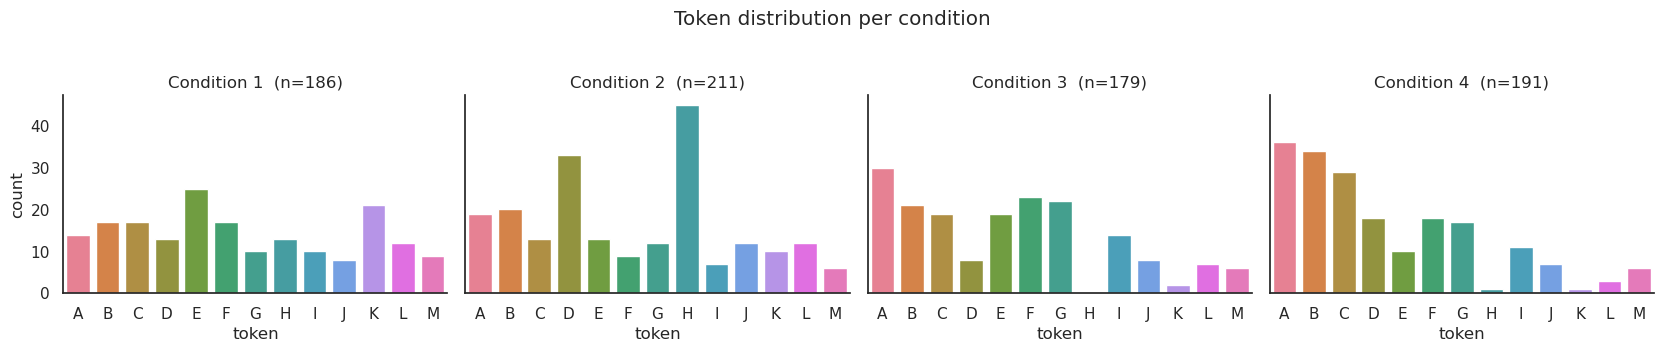

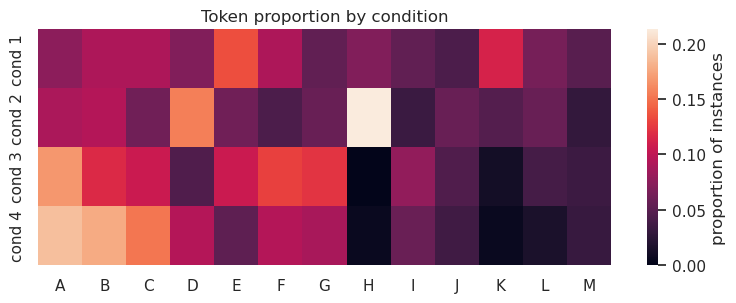

In [24]:
fig, axes = plt.subplots(1, len(conditions_present),
                         figsize=(4.2*len(conditions_present), 3.4), sharey=True)
if len(conditions_present) == 1:
    axes = [axes]
for ax, cond in zip(axes, conditions_present):
    mask = conditions == cond
    cnt  = Counter(letter_of[mask])
    ys   = [cnt.get(L, 0) for L in letters]
    sns.barplot(x=letters, y=ys, hue=letters, palette=letter_color, legend=False, ax=ax)
    ax.set_title(f"Condition {cond}  (n={int(mask.sum())})")
    ax.set_xlabel("token")
axes[0].set_ylabel("count")
fig.suptitle("Token distribution per condition", y=1.03)
sns.despine()
plt.tight_layout()
plt.show()

# also as normalised proportions, side by side
prop = np.zeros((len(conditions_present), n_codes))
for r, cond in enumerate(conditions_present):
    mask = conditions == cond
    cnt = Counter(letter_of[mask])
    tot = mask.sum()
    prop[r] = [cnt.get(L, 0)/tot for L in letters]
fig, ax = plt.subplots(figsize=(max(6, n_codes*0.6), 3.2))
sns.heatmap(prop, ax=ax, cmap="rocket", xticklabels=letters,
            yticklabels=[f"cond {c}" for c in conditions_present],
            cbar_kws={"label": "proportion of instances"})
ax.set_title("Token proportion by condition")
plt.tight_layout()
plt.show()

## Recurrence plots (per run, grouped by condition)

For each run (a contiguous same-condition sequence), point *(i, j)* is marked when
instance *i* and instance *j* carry the **same token** (categorical recurrence).
The **main diagonal** shows the token sequence itself, coloured by token identity;
off-diagonal points reuse that token's colour, so you can see *which* token recurs
and *when*.

- A **diagonal line** off the main diagonal = a repeated multi-token subsequence (a *motif*).
- A **block/thickening on the diagonal** = a token held over consecutive instances (a *dwell*).

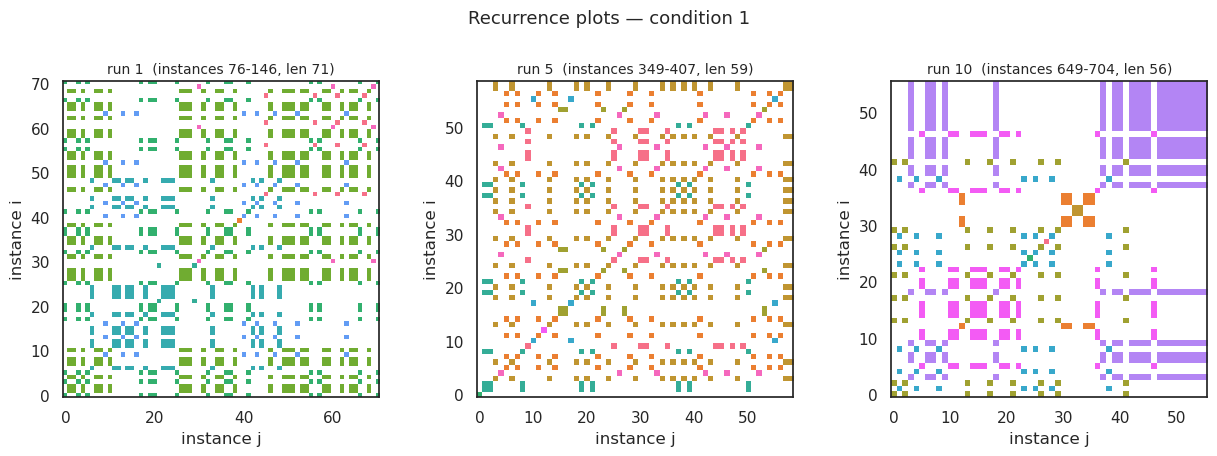

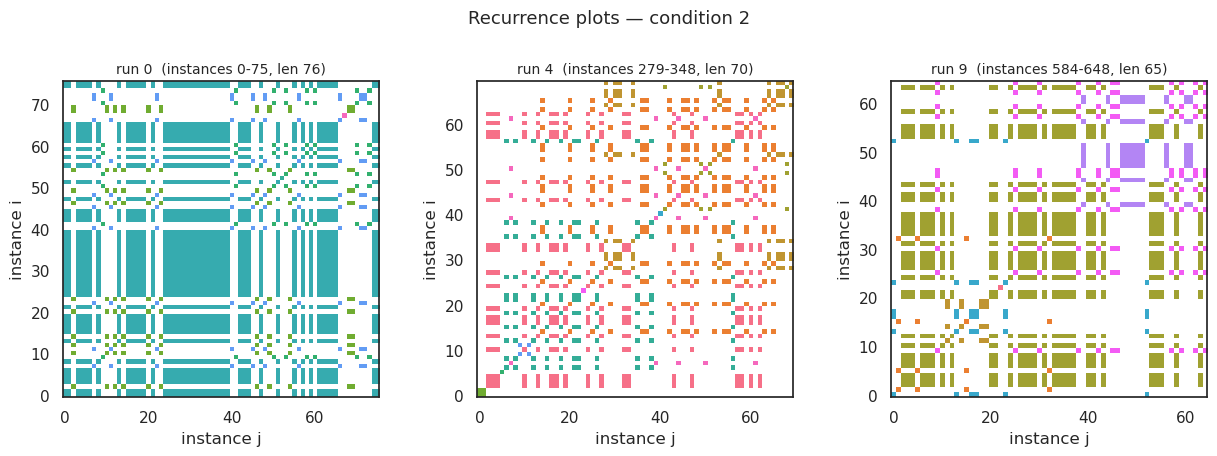

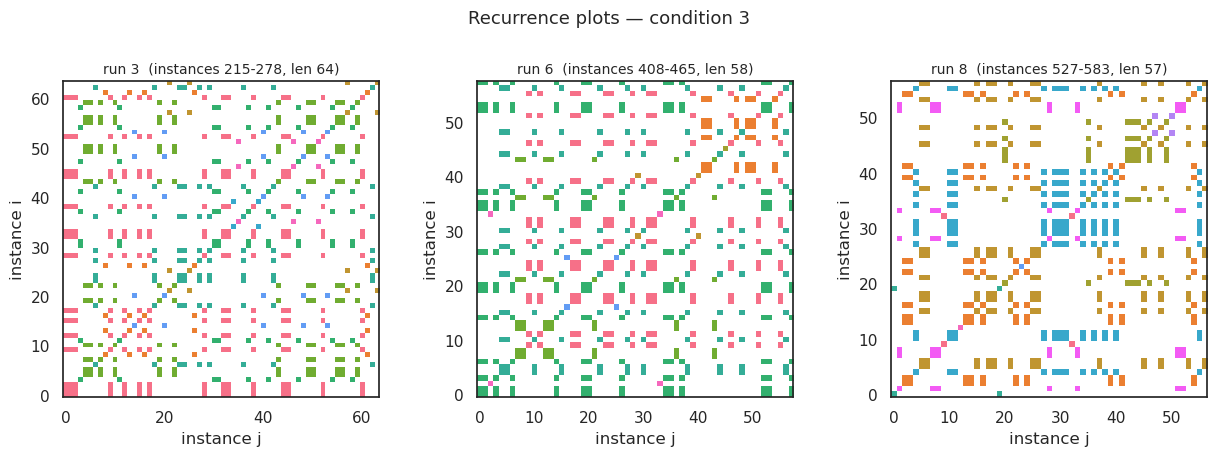

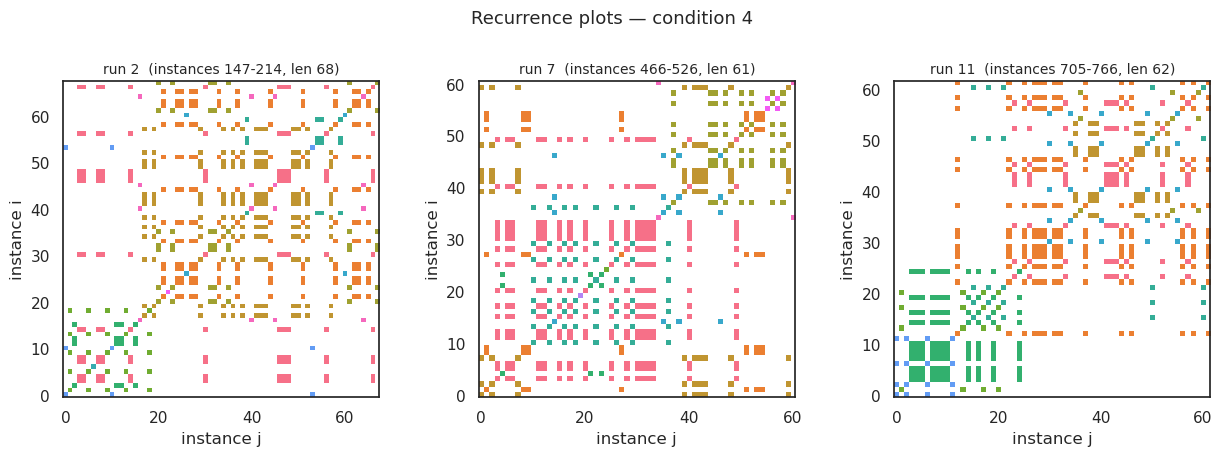

In [25]:
def recurrence_matrix(seq_letters):
    n = len(seq_letters)
    R = np.zeros((n, n), dtype=int)
    for i in range(n):
        R[i] = (seq_letters == seq_letters[i])
    return R

def plot_recurrence_run(ax, seq_letters, title):
    n = len(seq_letters)
    # coloured recurrence: each cell gets the colour of the token when recurrent
    img = np.ones((n, n, 3))
    for i in range(n):
        same = np.where(seq_letters == seq_letters[i])[0]
        col = letter_color[seq_letters[i]]
        for j in same:
            img[i, j] = col
    ax.imshow(img, origin="lower", interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("instance j"); ax.set_ylabel("instance i")

# group runs by condition
runs_by_cond = defaultdict(list)
for idx, (cond, s, e) in enumerate(runs):
    runs_by_cond[cond].append((idx, s, e))

for cond in conditions_present:
    group = runs_by_cond[cond]
    fig, axes = plt.subplots(1, len(group), figsize=(4.2*len(group), 4.2), squeeze=False)
    for col, (idx, s, e) in enumerate(group):
        seq = letter_of[s:e]
        plot_recurrence_run(axes[0][col], seq, f"run {idx}  (instances {s}-{e-1}, len {e-s})")
    fig.suptitle(f"Recurrence plots — condition {cond}", y=1.04, fontsize=13)
    plt.tight_layout()
    plt.show()

## Dwell analysis

A **dwell** is a run of consecutive identical tokens (length ≥ `MIN_DWELL_LEN`) —
the participant staying in the same token/state over multiple instances. Aggregated
per condition across its runs: how often it happens, how long, and on which token.

Dwells per condition (length >= 2):

cond  n_dwells  mean_len  max_len   tokens (count)
   1        28      2.46        9   E:8, K:4, H:3, L:3, F:2, A:2, C:2, B:2, G:1, D:1
   2        32      3.09       16   H:7, D:7, A:4, C:3, B:3, E:2, K:2, J:1, G:1, I:1, L:1
   3        30      2.10        3   A:6, E:5, F:5, B:4, C:3, G:2, L:2, I:2, D:1
   4        25      2.40        4   A:7, B:7, C:5, F:3, D:2, G:1


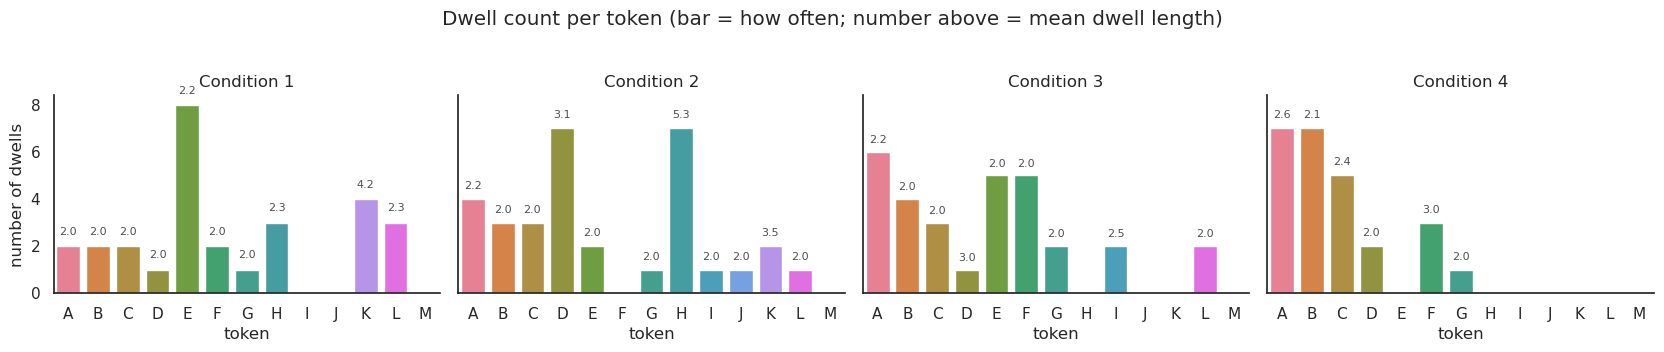

In [26]:
def find_dwells(seq_letters, min_len=MIN_DWELL_LEN):
    dwells = []   # (token, start, length)
    i = 0
    n = len(seq_letters)
    while i < n:
        j = i
        while j+1 < n and seq_letters[j+1] == seq_letters[i]:
            j += 1
        L = j - i + 1
        if L >= min_len:
            dwells.append((seq_letters[i], i, L))
        i = j + 1
    return dwells

dwell_rows = []
dwell_by_cond = {}
for cond in conditions_present:
    all_dw = []
    for (idx, s, e) in runs_by_cond[cond]:
        for (tok, st, L) in find_dwells(letter_of[s:e]):
            all_dw.append((tok, L))
    dwell_by_cond[cond] = all_dw
    if all_dw:
        lens = [L for _, L in all_dw]
        tokc = Counter(t for t, _ in all_dw)
        dwell_rows.append((cond, len(all_dw), np.mean(lens), max(lens),
                           ", ".join(f"{t}:{c}" for t, c in tokc.most_common())))
    else:
        dwell_rows.append((cond, 0, 0, 0, "-"))

print("Dwells per condition (length >= %d):\n" % MIN_DWELL_LEN)
print(f"{'cond':>4} {'n_dwells':>9} {'mean_len':>9} {'max_len':>8}   tokens (count)")
for cond, n, ml, mx, toks in dwell_rows:
    print(f"{cond:>4} {n:>9} {ml:>9.2f} {mx:>8}   {toks}")

# dwell COUNT per token per condition (bar height = how often that token is dwelled
# on); the mean dwell length is annotated on each bar (how long, on average).
fig, axes = plt.subplots(1, len(conditions_present),
                         figsize=(4.2*len(conditions_present), 3.4), sharey=True)
if len(conditions_present) == 1: axes = [axes]
for ax, cond in zip(axes, conditions_present):
    dw = dwell_by_cond[cond]                      # list of (token, length)
    n_by_tok = Counter(t for t, _ in dw)
    mean_len = {t: np.mean([L for tt, L in dw if tt == t]) for t in n_by_tok}
    # one bar per token, ALL tokens A,B,C.. (zero where a token has no dwells)
    counts_here = [n_by_tok.get(t, 0) for t in letters]
    sns.barplot(x=letters, y=counts_here, hue=letters, palette=letter_color,
                legend=False, ax=ax)
    ymax = max(counts_here + [1])
    for xi, t in enumerate(letters):              # annotate mean length above bars with dwells
        if n_by_tok.get(t, 0) > 0:
            ax.text(xi, n_by_tok[t] + 0.05*ymax,
                    f"{mean_len[t]:.1f}", ha="center", va="bottom", fontsize=8, color="0.3")
    ax.set_title(f"Condition {cond}")
    ax.set_xlabel("token")
axes[0].set_ylabel("number of dwells")
fig.suptitle("Dwell count per token (bar = how often; number above = mean dwell length)",
             y=1.03)
sns.despine(); plt.tight_layout(); plt.show()

## Motif analysis

A **motif** is a repeated subsequence of length ≥ `MIN_MOTIF_LEN` containing at least
two *distinct* tokens (so pure dwells are excluded — those are handled above). Motifs
are detected **within each run** (they cannot span a run boundary) and **pooled within
each condition** across its runs. Reported are the maximal motifs and how many times
each recurs.

Condition 1: 20 distinct motifs (len >= 3)
    EEF          x4
    FEE          x3
    HEE          x3
    EJE          x3
    CGC          x3
    HHJ          x2
    HJH          x2
    JFH          x2
    AEJ          x2
    EEJE         x2

Condition 2: 39 distinct motifs (len >= 3)
    HHHJ         x4
    DDL          x4
    DLD          x4
    HEH          x3
    JEH          x3
    EHJ          x3
    HJE          x3
    FHH          x3
    EHHHH        x3
    HHHHJ        x3

Condition 3: 9 distinct motifs (len >= 3)
    FEE          x2
    EFG          x2
    AFF          x2
    FFE          x2
    GAA          x2
    FGAC         x2
    BIC          x2
    BCC          x2
    CDK          x2

Condition 4: 11 distinct motifs (len >= 3)
    BAB          x3
    AAE          x2
    DBB          x2
    CBC          x2
    CCB          x2
    GAA          x2
    AGA          x2
    JFFF         x2
    FFFJ         x2
    GFEG         x2

Motif summary per condition (len >= 3, >= 2 d

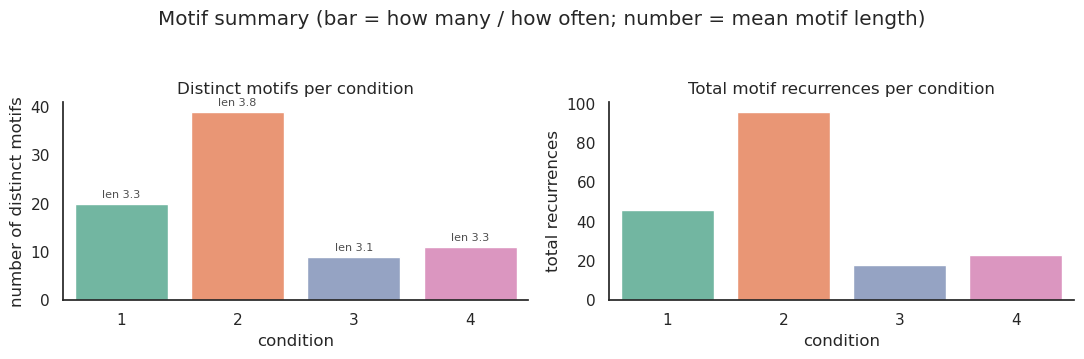

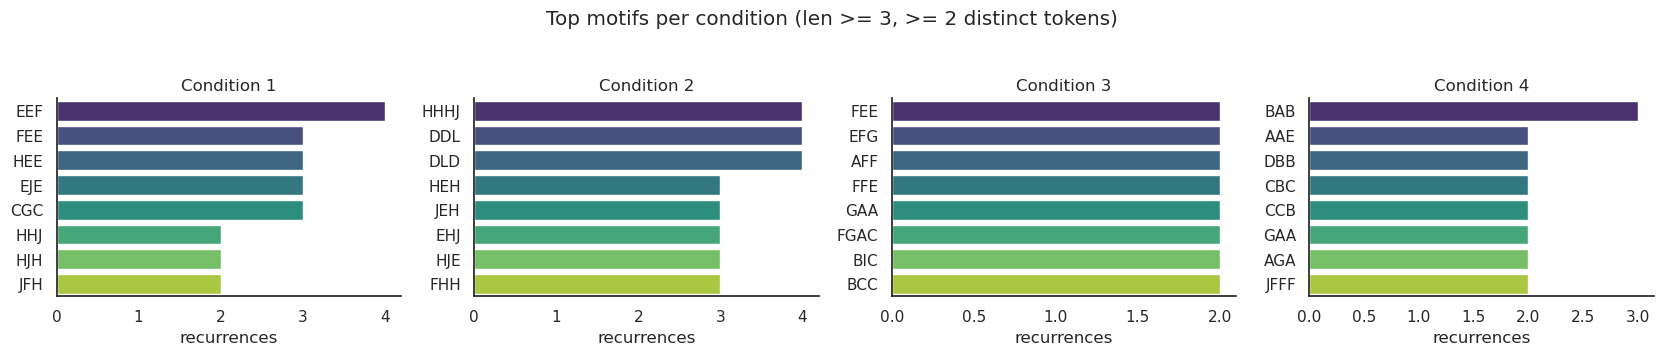

In [27]:
def _contains(big, small):
    return any(big[i:i+len(small)] == small for i in range(len(big)-len(small)+1))

def find_motifs(seq_list, min_len=MIN_MOTIF_LEN):
    n = len(seq_list); counts = Counter()
    for L in range(min_len, n//2 + 1):
        for i in range(n - L + 1):
            g = tuple(seq_list[i:i+L])
            if len(set(g)) >= 2:            # exclude pure dwells
                counts[g] += 1
    repeated = {m: c for m, c in counts.items() if c >= 2}
    # keep maximal: drop a motif if a longer motif with >= its count contains it
    maximal = {}
    for m, c in repeated.items():
        if not any(len(m2) > len(m) and c2 >= c and _contains(m2, m)
                   for m2, c2 in repeated.items()):
            maximal[m] = c
    return maximal

motif_by_cond = {}
for cond in conditions_present:
    pooled = Counter()
    for (idx, s, e) in runs_by_cond[cond]:
        for m, c in find_motifs(list(letter_of[s:e])).items():
            pooled[m] += c
    motif_by_cond[cond] = pooled

for cond in conditions_present:
    pooled = motif_by_cond[cond]
    print(f"Condition {cond}: {len(pooled)} distinct motifs (len >= {MIN_MOTIF_LEN})")
    for m, c in pooled.most_common(10):
        print(f"    {''.join(m):<12} x{c}")
    print()

# ── motif summary per condition (parallels the dwell summary) ──
motif_rows = []
for cond in conditions_present:
    pooled = motif_by_cond[cond]
    n_distinct = len(pooled)
    n_total    = sum(pooled.values())                       # total recurrences
    if pooled:
        lens = [len(m) for m in pooled.elements()]          # weight by recurrence count
        mean_len = np.mean(lens); max_len = max(len(m) for m in pooled)
        top_str  = ", ".join(f"{''.join(m)}:{c}" for m, c in pooled.most_common(3))
    else:
        mean_len = max_len = 0; top_str = "-"
    motif_rows.append((cond, n_distinct, n_total, mean_len, max_len, top_str))

print("Motif summary per condition (len >= %d, >= 2 distinct tokens):\n" % MIN_MOTIF_LEN)
print(f"{'cond':>4} {'distinct':>8} {'total_recur':>12} {'mean_len':>9} {'max_len':>8}   top motifs")
for cond, nd, nt, ml, mx, ts in motif_rows:
    print(f"{cond:>4} {nd:>8} {nt:>12} {ml:>9.2f} {mx:>8}   {ts}")

# summary bar chart: how many distinct motifs per condition + total recurrences,
# with mean motif length annotated (mirrors the dwell count chart)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
conds = [r[0] for r in motif_rows]
cond_pal = sns.color_palette("Set2", len(conds))
sns.barplot(x=[str(c) for c in conds], y=[r[1] for r in motif_rows],
            hue=[str(c) for c in conds], palette=cond_pal, legend=False, ax=axes[0])
for xi, r in enumerate(motif_rows):
    axes[0].text(xi, r[1] + 0.02*max([rr[1] for rr in motif_rows] + [1]),
                 f"len {r[3]:.1f}", ha="center", va="bottom", fontsize=8, color="0.3")
axes[0].set_title("Distinct motifs per condition"); axes[0].set_xlabel("condition")
axes[0].set_ylabel("number of distinct motifs")
sns.barplot(x=[str(c) for c in conds], y=[r[2] for r in motif_rows],
            hue=[str(c) for c in conds], palette=cond_pal, legend=False, ax=axes[1])
axes[1].set_title("Total motif recurrences per condition"); axes[1].set_xlabel("condition")
axes[1].set_ylabel("total recurrences")
fig.suptitle("Motif summary (bar = how many / how often; number = mean motif length)", y=1.05)
sns.despine(); plt.tight_layout(); plt.show()

# bar chart of the top motifs per condition
fig, axes = plt.subplots(1, len(conditions_present),
                         figsize=(4.2*len(conditions_present), 3.4))
if len(conditions_present) == 1: axes = [axes]
for ax, cond in zip(axes, conditions_present):
    top = motif_by_cond[cond].most_common(8)
    if top:
        names = ["".join(m) for m, _ in top]; vals = [c for _, c in top]
        sns.barplot(x=vals, y=names, hue=names, palette="viridis", legend=False, ax=ax)
    ax.set_title(f"Condition {cond}")
    ax.set_xlabel("recurrences")
fig.suptitle(f"Top motifs per condition (len >= {MIN_MOTIF_LEN}, >= 2 distinct tokens)", y=1.04)
sns.despine(); plt.tight_layout(); plt.show()

## RQA metrics

Recurrence Quantification Analysis scalars, per run and summarised per condition:

- **RR** (recurrence rate): fraction of recurrent points.
- **DET** (determinism): fraction of recurrent points forming diagonal lines (length ≥ 2) — how motif-driven the dynamics are.
- **L_mean / L_max**: mean and maximum diagonal line length.
- **LAM** (laminarity): fraction of recurrent points forming vertical lines — the dwell analogue.
- **TT** (trapping time): mean vertical line length — mean dwell duration.

In [28]:
def rqa_metrics(seq_letters, l_min=2):
    n = len(seq_letters)
    R = np.zeros((n, n), dtype=bool)
    for i in range(n):
        R[i] = seq_letters == seq_letters[i]
    rr = R.sum() / (n * n)
    # diagonal lines (exclude main diagonal), both directions symmetric so use offset>0
    diag_lengths = []
    for k in range(1, n):
        d = np.diagonal(R, offset=k)
        c = 0
        for v in d:
            if v: c += 1
            elif c: diag_lengths.append(c); c = 0
        if c: diag_lengths.append(c)
    diag_lengths = [L for L in diag_lengths if L >= l_min]
    n_diag_pts = 2 * sum(diag_lengths)             # symmetric
    det = n_diag_pts / R.sum() if R.sum() else 0
    l_mean = np.mean(diag_lengths) if diag_lengths else 0
    l_max  = max(diag_lengths) if diag_lengths else 0
    # vertical lines (laminarity / trapping time)
    vert_lengths = []
    for j in range(n):
        c = 0
        for i in range(n):
            if R[i, j]: c += 1
            elif c: vert_lengths.append(c); c = 0
        if c: vert_lengths.append(c)
    vert_lengths = [L for L in vert_lengths if L >= l_min]
    lam = sum(vert_lengths) / R.sum() if R.sum() else 0
    tt  = np.mean(vert_lengths) if vert_lengths else 0
    return dict(RR=rr, DET=det, L_mean=l_mean, L_max=l_max, LAM=lam, TT=tt)

print(f"{'run':>3} {'cond':>4} {'len':>4}  {'RR':>6} {'DET':>6} {'L_mean':>7} "
      f"{'L_max':>6} {'LAM':>6} {'TT':>6}")
per_cond_metrics = defaultdict(list)
for idx, (cond, s, e) in enumerate(runs):
    m = rqa_metrics(letter_of[s:e])
    per_cond_metrics[cond].append(m)
    print(f"{idx:>3} {cond:>4} {e-s:>4}  {m['RR']:>6.3f} {m['DET']:>6.3f} "
          f"{m['L_mean']:>7.2f} {m['L_max']:>6} {m['LAM']:>6.3f} {m['TT']:>6.2f}")

print("\nPer-condition mean:")
print(f"{'cond':>4}  {'RR':>6} {'DET':>6} {'L_mean':>7} {'L_max':>6} {'LAM':>6} {'TT':>6}")
for cond in conditions_present:
    ms = per_cond_metrics[cond]
    avg = {k: np.mean([mm[k] for mm in ms]) for k in ms[0]}
    print(f"{cond:>4}  {avg['RR']:>6.3f} {avg['DET']:>6.3f} {avg['L_mean']:>7.2f} "
          f"{avg['L_max']:>6.1f} {avg['LAM']:>6.3f} {avg['TT']:>6.2f}")

run cond  len      RR    DET  L_mean  L_max    LAM     TT
  0    2   76   0.400  0.626    3.28     15  0.738   5.08
  1    1   71   0.221  0.343    2.30      6  0.540   2.23
  2    4   68   0.129  0.228    2.12      3  0.419   2.21
  3    3   64   0.149  0.193    2.03      3  0.349   2.15
  4    2   70   0.170  0.281    2.25      4  0.384   2.12
  5    1   59   0.162  0.256    2.25      4  0.163   2.00
  6    3   58   0.174  0.240    2.19      4  0.452   2.00
  7    4   61   0.148  0.244    2.09      3  0.362   2.52
  8    3   57   0.162  0.194    2.12      3  0.432   2.18
  9    2   65   0.268  0.492    2.46      5  0.663   3.07
 10    1   56   0.225  0.470    2.63      8  0.649   3.55
 11    4   62   0.140  0.260    2.41      4  0.375   2.77

Per-condition mean:
cond      RR    DET  L_mean  L_max    LAM     TT
   1   0.203  0.356    2.40    6.0  0.451   2.59
   2   0.279  0.466    2.66    8.0  0.595   3.42
   3   0.161  0.209    2.12    3.3  0.411   2.11
   4   0.139  0.244    2.21  

## Transition matrices per condition

Token-to-token transition probabilities within each condition (transitions are
counted **within runs** only, never across run boundaries). Row = current token,
column = next token; each row is normalised to sum to 1. The diagonal reflects
dwelling (staying on the same token).

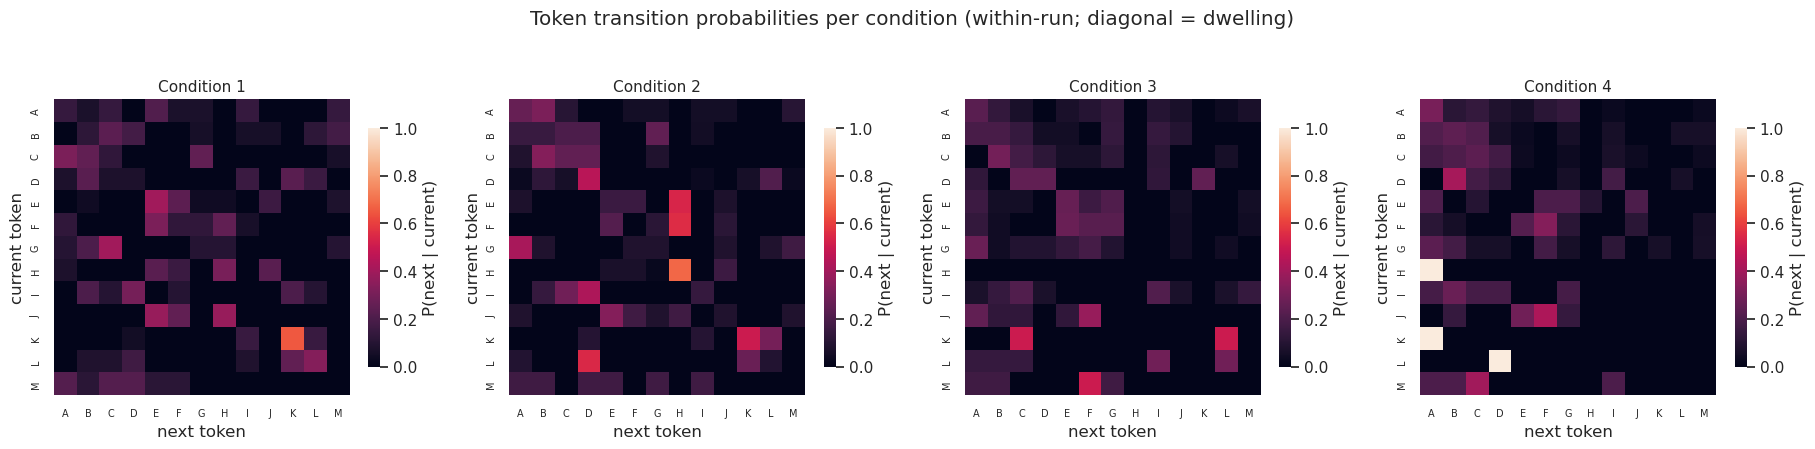

In [29]:
# integer token index per instance, in letter order (A=0, B=1, ...)
tok_idx = np.array([letters.index(L) for L in letter_of])

def transition_counts(cond):
    T = np.zeros((n_codes, n_codes))
    for (idx, s, e) in runs_by_cond[cond]:
        seq = tok_idx[s:e]
        for a, b in zip(seq[:-1], seq[1:]):
            T[a, b] += 1
    return T

fig, axes = plt.subplots(1, len(conditions_present),
                         figsize=(4.6*len(conditions_present), 4.2), squeeze=False)
for col, cond in enumerate(conditions_present):
    T = transition_counts(cond)
    rs = T.sum(1, keepdims=True)
    P = np.divide(T, rs, out=np.zeros_like(T), where=rs > 0)
    ax = axes[0][col]
    sns.heatmap(P, ax=ax, cmap="rocket", vmin=0, vmax=1, square=True,
                xticklabels=letters, yticklabels=letters,
                cbar_kws={"shrink": 0.7, "label": "P(next | current)"})
    ax.set_title(f"Condition {cond}", fontsize=11)
    ax.set_xlabel("next token"); ax.set_ylabel("current token")
    ax.tick_params(labelsize=7)
fig.suptitle("Token transition probabilities per condition "
             "(within-run; diagonal = dwelling)", y=1.03)
plt.tight_layout(); plt.show()

## Information-theoretic measures

- **Entropy** $H$ of the token distribution per condition (bits): how spread out the
  microstate usage is. Low $H$ = a focused state using few tokens; high $H$ = diffuse.
  The maximum is $\log_2 K$.
- **Mutual information** $I(\text{token};\text{condition})$: how much knowing the
  condition tells you about the token — a single number for how distinct the
  conditions' token usage is (0 = identical distributions).
- **Entropy rate** $h$ per condition: the uncertainty of the *next* token given the
  current one (from the transition matrix) — the predictability of the sequence, which
  can differ across conditions even when the marginal distributions are similar.
- **Jensen–Shannon divergence** of each condition's distribution from the overall
  distribution: how far each brain state departs from baseline (0 = identical).

Token-distribution entropy  (max log2 K = 3.70 bits)
  condition 1: H = 3.624 bits
  condition 2: H = 3.442 bits
  condition 3: H = 3.341 bits
  condition 4: H = 3.228 bits
  overall     : H = 3.595 bits

I(token; condition) = 0.1856 bits (5.163% of H(token))

Entropy rate  h (bits/step; lower = more predictable sequence)
  condition 1: h = 2.304
  condition 2: h = 2.054
  condition 3: h = 2.697
  condition 4: h = 2.567

Jensen-Shannon divergence from overall distribution
  condition 1: JS = 0.0269
  condition 2: JS = 0.0488
  condition 3: JS = 0.0629
  condition 4: JS = 0.0606


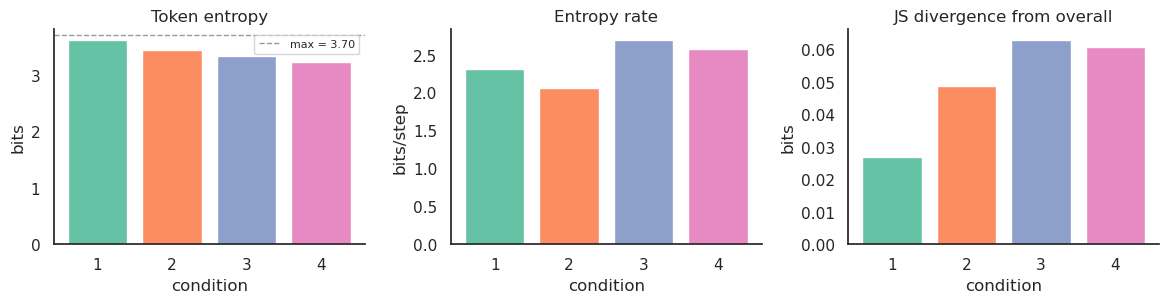

In [30]:
def _entropy(p):
    p = np.asarray(p, float); p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

def _dist(mask):
    c = np.bincount(tok_idx[mask], minlength=n_codes).astype(float)
    return c / c.sum() if c.sum() > 0 else c

overall_dist = _dist(np.ones(len(tok_idx), bool))
H_max = np.log2(n_codes)

# entropy per condition
print(f"Token-distribution entropy  (max log2 K = {H_max:.2f} bits)")
for cond in conditions_present:
    print(f"  condition {cond}: H = {_entropy(_dist(conditions == cond)):.3f} bits")
print(f"  overall     : H = {_entropy(overall_dist):.3f} bits")

# mutual information I(token; condition)
def mutual_information(cond_arr):
    N = len(tok_idx)
    ov = np.bincount(tok_idx, minlength=n_codes) / N
    mi = 0.0
    for cond in conditions_present:
        m = cond_arr == cond
        pc = m.mean()
        pt = _dist(m)
        for i in range(n_codes):
            if pt[i] > 0 and ov[i] > 0:
                mi += pc * pt[i] * np.log2(pt[i] / ov[i])
    return mi

MI = mutual_information(conditions)
print(f"\nI(token; condition) = {MI:.4f} bits "
      f"({MI/_entropy(overall_dist):.3%} of H(token))")

# entropy rate per condition (from within-run transition matrix)
def entropy_rate(cond):
    T = transition_counts(cond)
    rs = T.sum(1)
    if rs.sum() == 0: return 0.0
    pi = rs / rs.sum()
    return float(sum(pi[i] * _entropy(T[i]/rs[i]) for i in range(n_codes) if rs[i] > 0))

print("\nEntropy rate  h (bits/step; lower = more predictable sequence)")
for cond in conditions_present:
    print(f"  condition {cond}: h = {entropy_rate(cond):.3f}")

# Jensen-Shannon divergence vs overall
def _kl(p, q):
    m = (p > 0) & (q > 0); return float(np.sum(p[m]*np.log2(p[m]/q[m])))
def _js(p, q):
    mid = 0.5*(p+q); return 0.5*_kl(p, mid) + 0.5*_kl(q, mid)

print("\nJensen-Shannon divergence from overall distribution")
for cond in conditions_present:
    print(f"  condition {cond}: JS = {_js(_dist(conditions == cond), overall_dist):.4f}")

# small summary bar charts: entropy and JS per condition
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
cpal = sns.color_palette("Set2", len(conditions_present))
labels_c = [str(c) for c in conditions_present]
ax[0].bar(labels_c, [_entropy(_dist(conditions==c)) for c in conditions_present], color=cpal)
ax[0].axhline(H_max, ls="--", c="0.6", lw=1, label=f"max = {H_max:.2f}")
ax[0].set_title("Token entropy"); ax[0].set_ylabel("bits"); ax[0].legend(fontsize=8)
ax[1].bar(labels_c, [entropy_rate(c) for c in conditions_present], color=cpal)
ax[1].set_title("Entropy rate"); ax[1].set_ylabel("bits/step")
ax[2].bar(labels_c, [_js(_dist(conditions==c), overall_dist) for c in conditions_present], color=cpal)
ax[2].set_title("JS divergence from overall"); ax[2].set_ylabel("bits")
for a in ax: a.set_xlabel("condition")
sns.despine(); plt.tight_layout(); plt.show()

## Statistical tests of condition differences

**Design note.** The instances are treated as the population: the question is
whether the conditions use tokens differently *within this recording*. The 3 runs
per condition are counterbalancing to control order effects, not independent
replicates, so they are **not** used as the unit of analysis. The only statistical
nuisance is then the within-sequence autocorrelation (consecutive instances are
correlated — that is the dwell/motif structure), which reduces the effective sample
size. We measure that autocorrelation, then test with two methods that account for
it:

1. an **effective-N chi-square** on the token x condition table (the naive chi-square
   scaled by the measured effective sample size), and
2. a **block permutation** of the condition labels (shuffling contiguous blocks
   preserves local autocorrelation while breaking the token-condition association) —
   a distribution-free confirmation that needs no effective-N assumption.

Within-sequence autocorrelation (the nuisance being corrected for):
  P(token repeats next) = 0.233  vs 0.088 if independent (2.65x)
  mean lag-1 autocorrelation r1 = 0.156  ->  N_eff ~ 559 of 767

Chi-square (token x condition):
  naive         chi2 = 190.4, dof = 36, p = 6.58e-23
  effective-N   chi2 = 138.9 (scaled x0.73), p = 5.17e-14

Block-permutation test for I(token; condition)  (block size 10):
  observed MI = 0.1856 bits, null mean = 0.0791, p = 0.0008


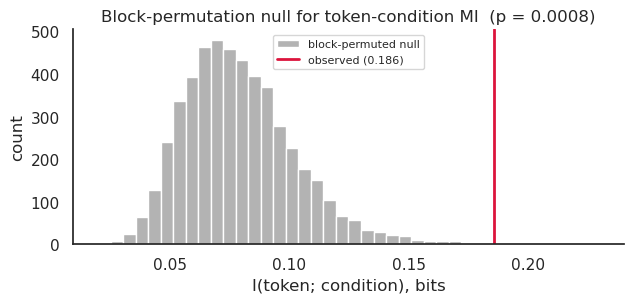


Interpretation: both the effective-N chi-square and the block permutation test whether
the conditions differ in token usage within this recording, accounting for autocorrelation.


In [31]:
from scipy.stats import chi2_contingency, chi2 as chi2dist

# ── 1. measure the within-sequence autocorrelation we must correct for ──
# (a) how much more often a token repeats than under independence
same = tot = 0
for (idx, s, e) in runs:
    seq = tok_idx[s:e]
    same += int(np.sum(seq[:-1] == seq[1:])); tot += len(seq) - 1
p_repeat = same / tot
p_marg   = np.bincount(tok_idx, minlength=n_codes) / len(tok_idx)
exp_repeat = float(np.sum(p_marg**2))
# (b) lag-1 autocorrelation averaged over token indicators -> effective-N factor
r1_num = r1_den = 0.0
for i in range(n_codes):
    x = (tok_idx == i).astype(float); xm = x.mean()
    for (idx, s, e) in runs:
        xs = x[s:e] - xm
        r1_num += np.sum(xs[:-1]*xs[1:]); r1_den += np.sum(xs*xs)
r1 = r1_num / r1_den
neff_factor = (1 - r1) / (1 + r1)
N = len(tok_idx); N_eff = N * neff_factor

print("Within-sequence autocorrelation (the nuisance being corrected for):")
print(f"  P(token repeats next) = {p_repeat:.3f}  vs {exp_repeat:.3f} if independent "
      f"({p_repeat/exp_repeat:.2f}x)")
print(f"  mean lag-1 autocorrelation r1 = {r1:.3f}  ->  N_eff ~ {N_eff:.0f} of {N}")

# ── 2. effective-N chi-square ──
ct = np.zeros((len(conditions_present), n_codes))
for r, cond in enumerate(conditions_present):
    ct[r] = np.bincount(tok_idx[conditions == cond], minlength=n_codes)
chi2, p_naive, dof, _ = chi2_contingency(ct)
p_eff = float(chi2dist.sf(chi2 * neff_factor, dof))
print(f"\nChi-square (token x condition):")
print(f"  naive         chi2 = {chi2:.1f}, dof = {dof}, p = {p_naive:.2e}")
print(f"  effective-N   chi2 = {chi2*neff_factor:.1f} (scaled x{neff_factor:.2f}), "
      f"p = {p_eff:.2e}")

# ── 3. block-permutation test on I(token; condition) ──
def block_perm_labels(arr, bs, rng):
    n = len(arr); nb = int(np.ceil(n / bs))
    blocks = [arr[i*bs:(i+1)*bs] for i in range(nb)]
    return np.concatenate([blocks[i] for i in rng.permutation(nb)])[:n]

BLOCK = 10                                  # ~ a few mean dwell lengths
rng = np.random.default_rng(0); N_PERM = 5000
obs_mi = mutual_information(conditions)
perm_mi = np.array([mutual_information(block_perm_labels(conditions, BLOCK, rng))
                    for _ in range(N_PERM)])
p_block = (np.sum(perm_mi >= obs_mi) + 1) / (N_PERM + 1)
print(f"\nBlock-permutation test for I(token; condition)  (block size {BLOCK}):")
print(f"  observed MI = {obs_mi:.4f} bits, null mean = {perm_mi.mean():.4f}, "
      f"p = {p_block:.4f}")

# visualise the block-permutation null vs observed
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.hist(perm_mi, bins=40, color="0.7", label="block-permuted null")
ax.axvline(obs_mi, color="crimson", lw=2, label=f"observed ({obs_mi:.3f})")
ax.set_xlabel("I(token; condition), bits"); ax.set_ylabel("count")
ax.set_title(f"Block-permutation null for token-condition MI  (p = {p_block:.4f})")
ax.legend(fontsize=8); sns.despine(); plt.tight_layout(); plt.show()

print("\nInterpretation: both the effective-N chi-square and the block permutation "
      "test whether\nthe conditions differ in token usage within this recording, "
      "accounting for autocorrelation.")

## Significance tests for the information-theoretic measures

Each of entropy, entropy rate, and JS-divergence-from-overall is tested with the same
**block-permutation** null used above (contiguous label blocks shuffled, preserving
within-sequence autocorrelation), so results are consistent and account for the
temporal dependence.

- **Omnibus**: does the measure differ *across* conditions at all? Statistic = the
  spread (max − min) of the per-condition values; null = block-permuted spreads.
- **Per-condition**: does a given condition's value stand out from what block
  permutation produces? For entropy and entropy rate this is two-sided (a condition
  may be unusually high or low); for JS-from-overall it is one-sided (departure is
  always ≥ 0).

In [32]:
def _dist_of(mask):
    c = np.bincount(tok_idx[mask], minlength=n_codes).astype(float)
    return c / c.sum() if c.sum() > 0 else c

def _runs_of(cond_arr):
    ch = np.where(np.diff(cond_arr) != 0)[0] + 1
    bd = np.concatenate([[0], ch, [len(cond_arr)]])
    return [(int(cond_arr[bd[i]]), int(bd[i]), int(bd[i+1])) for i in range(len(bd)-1)]

# per-condition measures as functions of an arbitrary label array
def _cond_entropy(ca, cc):
    return _entropy(_dist_of(ca == cc))

def _cond_js(ca, cc):
    ov = np.bincount(tok_idx, minlength=n_codes) / len(tok_idx)
    return _js(_dist_of(ca == cc), ov)

def _cond_entropy_rate(ca, cc):
    T = np.zeros((n_codes, n_codes))
    for c, s, e in _runs_of(ca):
        if c != cc: continue
        seq = tok_idx[s:e]
        for a, b in zip(seq[:-1], seq[1:]): T[a, b] += 1
    rs = T.sum(1)
    if rs.sum() == 0: return 0.0
    pi = rs / rs.sum()
    return float(sum(pi[i]*_entropy(T[i]/rs[i]) for i in range(n_codes) if rs[i] > 0))

MEASURES = {"entropy": _cond_entropy,
            "entropy_rate": _cond_entropy_rate,
            "JS_from_overall": _cond_js}
ONE_SIDED = {"entropy": False, "entropy_rate": False, "JS_from_overall": True}

# observed per-condition values
obs = {name: {cc: fn(conditions, cc) for cc in conditions_present}
       for name, fn in MEASURES.items()}

# block-permutation null
rng = np.random.default_rng(0)
N_PERM_IT = 3000; BLOCK_IT = 10
null_vals   = {name: {cc: [] for cc in conditions_present} for name in MEASURES}
null_spread = {name: [] for name in MEASURES}
for _ in range(N_PERM_IT):
    ca = block_perm_labels(conditions, BLOCK_IT, rng)
    for name, fn in MEASURES.items():
        vals = {cc: fn(ca, cc) for cc in conditions_present}
        for cc in conditions_present:
            null_vals[name][cc].append(vals[cc])
        null_spread[name].append(max(vals.values()) - min(vals.values()))

def _p_geq(o, null):
    null = np.asarray(null); return (np.sum(null >= o) + 1) / (len(null) + 1)
def _p_two(o, null):
    null = np.asarray(null); c = null.mean()
    return (np.sum(np.abs(null - c) >= abs(o - c)) + 1) / (len(null) + 1)

# omnibus
print("Omnibus (spread across conditions vs block-permuted null):")
for name in MEASURES:
    o = max(obs[name].values()) - min(obs[name].values())
    print(f"  {name:<16} spread = {o:.4f}   p = {_p_geq(o, null_spread[name]):.4f}")

# per-condition
print("\nPer-condition p-values:")
print(f"{'cond':>4}   {'entropy':>18}   {'entropy_rate':>18}   {'JS_from_overall':>18}")
for cc in conditions_present:
    cells = []
    for name in MEASURES:
        o = obs[name][cc]; nl = null_vals[name][cc]
        p = _p_geq(o, nl) if ONE_SIDED[name] else _p_two(o, nl)
        cells.append(f"{o:.3f} (p={p:.3f})")
    print(f"{cc:>4}   {cells[0]:>18}   {cells[1]:>18}   {cells[2]:>18}")

Omnibus (spread across conditions vs block-permuted null):
  entropy          spread = 0.3957   p = 0.0017
  entropy_rate     spread = 0.6424   p = 0.0017
  JS_from_overall  spread = 0.0360   p = 0.1083

Per-condition p-values:
cond              entropy         entropy_rate      JS_from_overall
   1      3.624 (p=0.085)      2.304 (p=0.376)      0.027 (p=0.242)
   2      3.442 (p=0.165)      2.054 (p=0.000)      0.049 (p=0.016)
   3      3.341 (p=0.023)      2.697 (p=0.007)      0.063 (p=0.009)
   4      3.228 (p=0.001)      2.567 (p=0.200)      0.061 (p=0.007)


### Observed values against their permutation nulls

Each panel shows, per condition, the observed measure (point) over the block-permuted
null distribution (violin). Points lying outside the bulk of their violin are the
conditions that differ significantly.

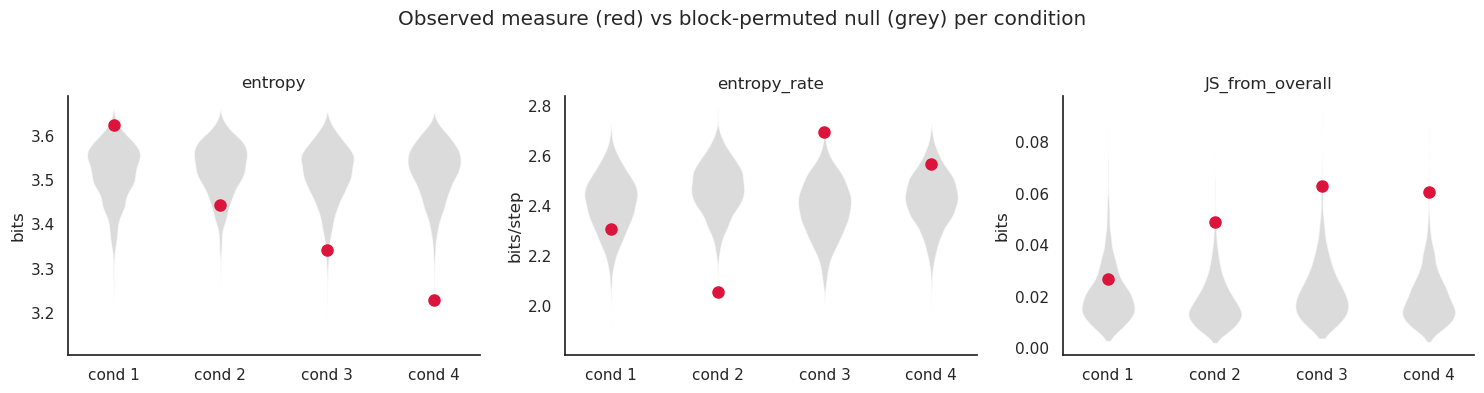

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, name in zip(axes, MEASURES):
    # build long-form null for violins
    data = []; positions = []
    for xi, cc in enumerate(conditions_present):
        data.append(null_vals[name][cc]); positions.append(xi)
    parts = ax.violinplot(data, positions=positions, showextrema=False)
    for pc in parts["bodies"]:
        pc.set_facecolor("0.8"); pc.set_alpha(0.7)
    for xi, cc in enumerate(conditions_present):
        ax.plot(xi, obs[name][cc], "o", color="crimson", zorder=5, ms=8)
    ax.set_xticks(range(len(conditions_present)))
    ax.set_xticklabels([f"cond {c}" for c in conditions_present])
    ax.set_title(name)
    ax.set_ylabel("bits" + ("/step" if name == "entropy_rate" else ""))
fig.suptitle("Observed measure (red) vs block-permuted null (grey) per condition", y=1.03)
sns.despine(); plt.tight_layout(); plt.show()